# Exercises¶

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')
from io import BytesIO
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
np.random.seed(0) # Reproducibility

* Read the Airline passenger dataset and perform some general statistical test as well as data visulalization.

In [ ]:
#def run_sequence_plot(x, y, )

#def plotting()

Based on the plots,and statisticals informations discuss if the dataset seems to be stationary or not.

---

Use the following tools to determine if the airline passenger dataset is stationary or not.

1. Summary statistics on the chunks.
2. Augmented Dickey-Fuller test.
Discuss the result obtained with each method.


In [13]:
df = pd.read_csv('AirPassengers.csv', index_col='Month', parse_dates=['Month'])
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [12]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[us]', name='Month', length=144, freq=None)

In [14]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


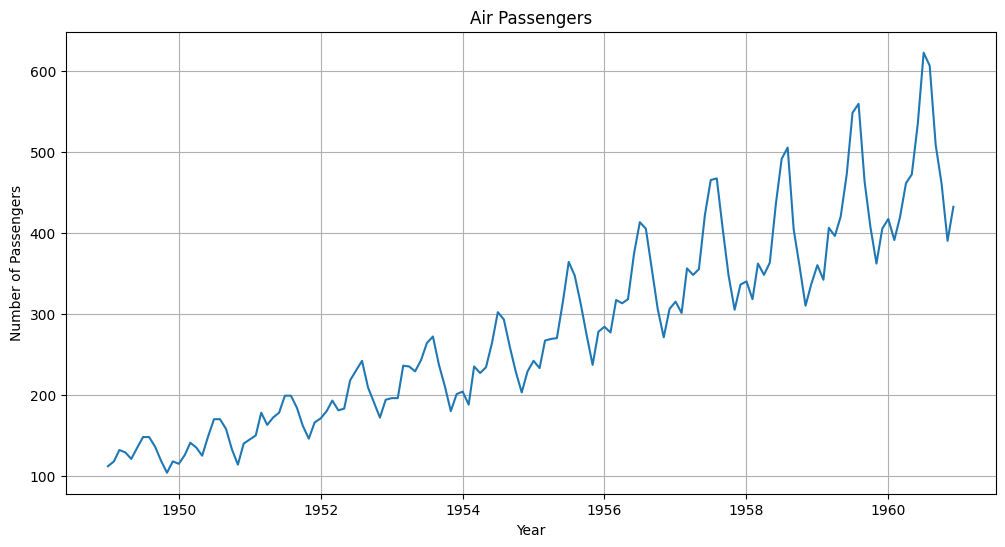

In [18]:
def run_sequence_plot(x, y, title='', xlabel='', ylabel=''):
    plt.figure(figsize=(12, 6))
    plt.plot(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.show()
run_sequence_plot(df.index, df['#Passengers'], title='Air Passengers', xlabel='Year', ylabel='Number of Passengers')

In [23]:
chunks=np.split(df['#Passengers'], indices_or_sections=12)
#chunks=np.split(df['#Passengers'].iloc[0:100], indices_or_sections=10)

df['#Passengers'].loc['1949-01-01':'1960-01-01']

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1959-09-01    463
1959-10-01    407
1959-11-01    362
1959-12-01    405
1960-01-01    417
Name: #Passengers, Length: 133, dtype: int64

In [5]:
# summary statistics on the chunks
def summary_statistics(data, chunk_size):
    num_chunks = len(data) // chunk_size
    stats = []
    for i in range(num_chunks):
        chunk = data[i*chunk_size:(i+1)*chunk_size]
        stats.append({
            'mean': np.mean(chunk),
            'std': np.std(chunk),
            'min': np.min(chunk),
            '25%': np.percentile(chunk, 25),
            '50%': np.percentile(chunk, 50),
            '75%': np.percentile(chunk, 75),
            'max': np.max(chunk)
        })
    return pd.DataFrame(stats)

# How do I find out if it is stationary or not? I have to do the ADF test, right?
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))  

result=adf_test(data['#Passengers'])
         

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


---

In [25]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(df['#Passengers'])
print(f'ADF Statistic: {adf:.2f}')
print(f'p-value: {pvalue:.2f}')


ADF Statistic: 0.82
p-value: 0.99


If the dataset is nonstationary, apply the methods you learned to make it so. Then apply the methods you learned to ensure stationarity.

In [ ]:
df['Passenger_diff'] = df['#Passengers'].diff()
df['Passenger_diff']
plotting(title='Airpassenger', data=df,x=df.index,y='Passenger_diff', x_label='Date', y_label='Difference in Passengers')

Month
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: Passenger_diff, Length: 144, dtype: float64

- Load the two time series `stationarity_ts1` and `stationarity_ts2` by running the code below.
  

In [ ]:
df['pass_log'] = np.log(df['#Passengers'])
plotting(title='Airpassenger', data=df,x=df.index,y='pass_log', x_label='Date', y_label='Log of Passengers<br>log transform')

In [ ]:
df['pass_log_diff'] = df['pass_log'].diff()

In [16]:
# Load the first time series
stationarity_ts1 = np.load('stationarity_ts1.npy')
print(len(stationarity_ts1))

stationarity_ts2 = np.load('stationarity_ts2.npy')
print(len(stationarity_ts2))

100
100


1. Plot the two time series with a run sequence plot.
4. Based on the plot, discuss if each time series seems to be stationary or not.

Use the following tools to determine if the time series `stationarity_ts1` and `stationarity_ts2` are stationary or not.

1. Summary statistics on the chunks.
2. Augmented Dickey-Fuller test.
Discuss the result obtained with each method.

---

If either or both datasets from exercises one and two are nonstationary, apply the transformations you learned in this section to make them so. Then apply the methods you learned to ensure stationarity.

If either or both datasets from exercises one and two are nonstationary, apply the transformations you learned in this section to make them so. Then apply the methods you learned to ensure stationarity.